In [49]:
from Functions.Graphs import *
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import re

def build_pure_convolutional_encoder(input_shape=(25600, 1), latent_dim=128):
    """
    Constrói apenas o Extrator de Características (Encoder) sem as cabeças
    de decisão. Transforma (25600, 1) em um vetor latente de (latent_dim,).
    """
    inputs = layers.Input(shape=input_shape, name="raw_vibration_input")
    
    # Camada 1: Filtro longo (64) para varrer dinâmicas macro do sinal mecânico
    x = layers.Conv1D(filters=32, kernel_size=128, strides=4, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=4)(x)
    
    # Camada 2: Filtros intermediários (16) para transientes e choques repetitivos
    x = layers.Conv1D(filters=64, kernel_size=32, strides=4, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    # Camada 3: Filtros curtos (5) para extrair micro-assinaturas de modulação
    x = layers.Conv1D(filters=latent_dim, kernel_size=5, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    # Redução espacial final: Extrai a média global de energia de cada um dos 128 filtros
    latent_space = layers.GlobalAveragePooling1D(name="extracted_features")(x)
    
    # Define o modelo contendo apenas a estrutura de extração
    encoder_model = Model(inputs=inputs, outputs=latent_space, name="Vibration_Encoder_1D")
    
    return encoder_model


In [53]:
nfeatures = 32
path = r'C:\Users\Usuário\Desktop\Python\Datasets\DATASET_XJTU'
brngs = os.listdir(path)
brngs.sort(key=lambda x: int(re.search(r'\d+', x).group()))
for i,brng in enumerate(brngs):
#for i,brng in enumerate(brngs[::-1]):
    brng_path = os.path.join(path,brng)
    samples = os.listdir(brng_path)
    samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
    X = []
    for sample in samples:
        df = pd.read_csv(os.path.join(brng_path, sample))
        sig = df['Horizontal_vibration_signals'].values
        X.append(sig.reshape(-1, 1))
    X = np.array(X)
    if i==0:
        encoder = build_pure_convolutional_encoder(input_shape=(X.shape[1], 1), latent_dim=nfeatures)
    Z = encoder.predict(X)
    df = pd.DataFrame(Z)
    df.columns = [f'F{j+1}' for j in range(nfeatures)]
    out = f'Dataset/XJTU/DSI3/'
    os.makedirs(out,exist_ok=True)
    df.to_csv(out+f'{brng}.csv',index=False)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [ ]:
normalize_df

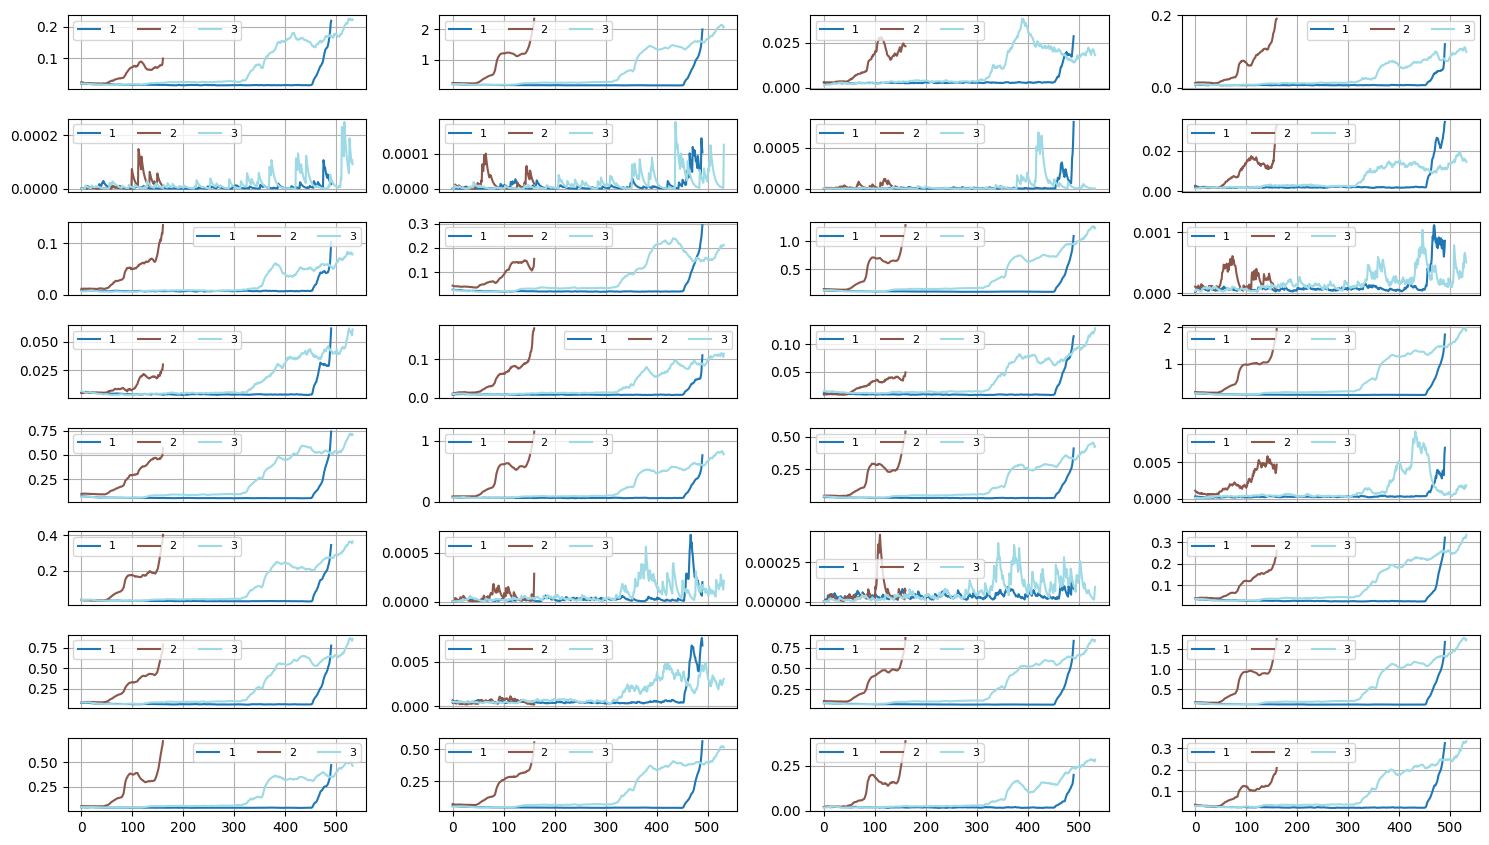

In [56]:
path = r'Dataset\XJTU\DSI3'
brngs = ['Bearing2_1.csv','Bearing2_2.csv', 'Bearing2_3.csv'][:]
dataframes = [(pd.read_csv(os.path.join(path,brng))) for brng in brngs]
#dataframes = [normalize_df(df) for df in dataframes]
dataframes = [exponential_moving_average_df(df,alpha=0.15) for df in dataframes]
PlotDataframes(dataframes,w=15,h=9)